<a href="https://colab.research.google.com/github/krishjaiswal27/Nifty50-Exploratory-Data-Analysis/blob/main/Nifty50_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import os, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [22]:
files = glob.glob('/content/drive/MyDrive/eda/nifty50_data/**/*.csv', recursive=True)
print(f"Found {len(files)} CSV files")
print(files[:5])

Found 50 CSV files
['/content/drive/MyDrive/eda/nifty50_data/ADANIPORTS.csv', '/content/drive/MyDrive/eda/nifty50_data/ADANIENT.csv', '/content/drive/MyDrive/eda/nifty50_data/HCLTECH.csv', '/content/drive/MyDrive/eda/nifty50_data/NTPC.csv', '/content/drive/MyDrive/eda/nifty50_data/TECHM.csv']


In [23]:
sample = pd.read_csv(files[0])
print(sample.columns.tolist())
sample.head()

['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


,Date,Open,High,Low,Close,Adj Close,Volume
0,2007-11-27,154.000000,207.000000,154.000000,191.800003,174.525635,27262365
1,2007-11-28,194.000000,197.800003,174.929993,177.000000,161.058563,21958915
2,2007-11-29,181.000000,182.800003,168.460007,177.399994,161.422546,25616715
3,2007-11-30,178.000000,191.399994,178.000000,185.800003,169.066010,23047035
4,2007-12-03,187.949997,198.860001,184.399994,196.000000,178.347366,14578850


In [24]:
all_dfs = []
for filepath in files:
  symbol = os.path.splitext(os.path.basename(filepath))[0]
  temp_df = pd.read_csv(filepath)
  temp_df['symbol'] = symbol
  all_dfs.append(temp_df)

df = pd.concat(all_dfs, ignore_index=True)
print(df.shape)
df.head()

(290684, 15)


,Date,Open,High,Low,Close,Adj Close,Volume,symbol,Price,Adj Close.1,Close.1,High.1,Low.1,Open.1,Volume.1
0,2007-11-27,154.0,207.0,154.0,191.800003,174.525635,27262365,ADANIPORTS,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2007-11-28,194.0,197.800003,174.929993,177.0,161.058563,21958915,ADANIPORTS,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2007-11-29,181.0,182.800003,168.460007,177.399994,161.422546,25616715,ADANIPORTS,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2007-11-30,178.0,191.399994,178.0,185.800003,169.06601,23047035,ADANIPORTS,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2007-12-03,187.949997,198.860001,184.399994,196.0,178.347366,14578850,ADANIPORTS,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
print(f"Files combined: {len(files)}")
print(f"Unique symbols in df: {df['symbol'].nunique()}")
print(df.columns.tolist())
df.groupby('symbol').size().sort_values(ascending=False)

Files combined: 50
Unique symbols in df: 50
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'symbol', 'Price', 'Adj Close.1', 'Close.1', 'High.1', 'Low.1', 'Open.1', 'Volume.1']


,0
symbol,
TATAMOTORS,8600
HDFCBANK,7297
HINDUNILVR,7297
SUNPHARMA,7297
TATASTEEL,7297
WIPRO,7297
HINDALCO,7297
INFY,7297
TITAN,7297


In [26]:
print(df.shape)
print(df.columns.tolist())
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
print(df.head())
print(df['Date'].min() if 'Date' in df.columns else 'no Date column found')
df.groupby('symbol').size().describe()

(290684, 15)
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'symbol', 'Price', 'Adj Close.1', 'Close.1', 'High.1', 'Low.1', 'Open.1', 'Volume.1']
        Date        Open        High         Low       Close   Adj Close  \
0 2007-11-27       154.0       207.0       154.0  191.800003  174.525635   
1 2007-11-28       194.0  197.800003  174.929993       177.0  161.058563   
2 2007-11-29       181.0  182.800003  168.460007  177.399994  161.422546   
3 2007-11-30       178.0  191.399994       178.0  185.800003   169.06601   
4 2007-12-03  187.949997  198.860001  184.399994       196.0  178.347366   

     Volume      symbol Price Adj Close.1 Close.1 High.1 Low.1 Open.1 Volume.1  
0  27262365  ADANIPORTS   NaN         NaN     NaN    NaN   NaN    NaN      NaN  
1  21958915  ADANIPORTS   NaN         NaN     NaN    NaN   NaN    NaN      NaN  
2  25616715  ADANIPORTS   NaN         NaN     NaN    NaN   NaN    NaN      NaN  
3  23047035  ADANIPORTS   NaN         NaN     NaN    NaN

,0
count,50.000000
mean,5813.680000
std,1701.444554
min,2.000000
25%,5568.250000
50%,5600.000000
75%,7294.000000
max,8600.000000


In [17]:
keep_cols = ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'symbol']
df_real = df[keep_cols].copy()

print(df_real.shape)
print(df_real['Date'].min(), df_real['Date'].max())
df_real.groupby('symbol').size().sort_values().head()

(290684, 8)
1991-01-02 00:00:00 2025-01-17 00:00:00


,0
symbol,
NIFTY 50,2
HDFCLIFE,1770
SBILIFE,1802
LTIM,2098
COALINDIA,3502


In [28]:
df = df[['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'symbol']].copy()
print(df.shape)
print(df.isnull().sum())

(290683, 8)
Date         1
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
symbol       0
dtype: int64


In [83]:
df = df[df['symbol'] != 'NIFTY 50'].copy()

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['symbol', 'Date']).reset_index(drop=True)

print("Missing values:")
print(df.isnull().sum())
print(f"Duplicate (symbol, Date) rows: {df.duplicated(subset=['symbol', 'Date']).sum()}")
df = df.drop_duplicates(subset=['symbol', 'Date'])

print(df.shape)
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Unique symbols: {df['symbol'].nunique()}")

Missing values:
Date             0
Open             0
High             0
Low              0
Close            0
Adj Close        0
Volume           0
symbol           0
daily_return    49
dtype: int64
Duplicate (symbol, Date) rows: 0
(290682, 9)
Date range: 1991-01-02 00:00:00 to 2025-01-17 00:00:00
Unique symbols: 49


In [84]:
print(df[df['Date'].isnull()])
df = df.dropna(subset=['Date'])
print(df.shape)

Empty DataFrame
Columns: [Date, Open, High, Low, Close, Adj Close, Volume, symbol, daily_return]
Index: []
(290682, 9)


In [85]:
print(df['symbol'].unique())
df.groupby('symbol').size().sort_values().head()

['ADANIENT' 'ADANIPORTS' 'APOLLOHOSP' 'ASIANPAINT' 'AXISBANK' 'BAJAJ-AUTO'
 'BAJAJFINSV' 'BAJFINANCE' 'BHARTIARTL' 'BPCL' 'BRITANNIA' 'CIPLA'
 'COALINDIA' 'DIVISLAB' 'DRREDDY' 'EICHERMOT' 'GRASIM' 'HCLTECH'
 'HDFCBANK' 'HDFCLIFE' 'HEROMOTOCO' 'HINDALCO' 'HINDUNILVR' 'ICICIBANK'
 'INDUSINDBK' 'INFY' 'ITC' 'JSWSTEEL' 'KOTAKBANK' 'LT' 'LTIM' 'MARUTI'
 'NESTLEIND' 'NTPC' 'ONGC' 'POWERGRID' 'RELIANCE' 'SBILIFE' 'SBIN'
 'SUNPHARMA' 'TATACONSUM' 'TATAMOTORS' 'TATASTEEL' 'TCS' 'TECHM' 'TITAN'
 'ULTRACEMCO' 'UPL' 'WIPRO']


,0
symbol,
HDFCLIFE,1770
SBILIFE,1802
LTIM,2098
COALINDIA,3502
ADANIPORTS,4225


In [86]:
numeric_cols = [
    'Open',
    'High',
    'Low',
    'Close',
    'Adj Close',
    'Volume'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )

In [87]:
df['daily_return'] = df.groupby('symbol')['Adj Close'].pct_change()
df[['symbol', 'Date', 'Adj Close', 'daily_return']].head(10)

,symbol,Date,Adj Close,daily_return
0,ADANIENT,2002-07-01,-0.010443,NaN
1,ADANIENT,2002-07-02,-0.010525,0.007874
2,ADANIENT,2002-07-03,-0.010525,0.000000
3,ADANIENT,2002-07-04,-0.010584,0.005581
4,ADANIENT,2002-07-05,-0.010560,-0.002220
5,ADANIENT,2002-07-08,-0.011024,0.043938
6,ADANIENT,2002-07-09,-0.010737,-0.026105
7,ADANIENT,2002-07-10,-0.010725,-0.001094
8,ADANIENT,2002-07-11,-0.010549,-0.016429
9,ADANIENT,2002-07-12,-0.010631,0.007795


In [88]:
df_clean = df[
    (df['daily_return'] > -1) &
    (df['daily_return'] < 1)
].copy()

In [89]:
TRADING_DAYS = 252

summary = df_clean.groupby('symbol')['daily_return'].agg(
    avg_daily_return='mean',
    daily_volatility='std',
    n_days='count'
).reset_index()

summary['annualized_return'] = summary['avg_daily_return'] * TRADING_DAYS
summary['annualized_volatility'] = summary['daily_volatility'] * np.sqrt(TRADING_DAYS)
summary['return_per_unit_risk'] = summary['annualized_return'] / summary['annualized_volatility']

summary = summary.sort_values('return_per_unit_risk', ascending=False)
summary.head(15)

,symbol,avg_daily_return,daily_volatility,n_days,annualized_return,annualized_volatility,return_per_unit_risk
13,DIVISLAB,0.001502,0.023010,5419,0.378466,0.365280,1.036098
30,LTIM,0.001292,0.020670,2097,0.325572,0.328131,0.992200
3,ASIANPAINT,0.001017,0.016547,5598,0.256333,0.262672,0.975867
25,INFY,0.001407,0.023792,7296,0.354576,0.377693,0.938793
0,ADANIENT,0.001992,0.034932,5597,0.501961,0.554534,0.905194
10,BRITANNIA,0.001061,0.018783,7295,0.267465,0.298171,0.897019
39,SUNPHARMA,0.001241,0.022935,7296,0.312773,0.364088,0.859057
18,HDFCBANK,0.001116,0.020938,7296,0.281245,0.332377,0.846165
7,BAJFINANCE,0.001520,0.028913,5597,0.383069,0.458982,0.834606
5,BAJAJ-AUTO,0.001033,0.019885,5601,0.260320,0.315671,0.824658


In [90]:
fig = px.scatter(
    summary, x='annualized_volatility', y='annualized_return',
    size='n_days', color='n_days',
    hover_name='symbol', hover_data=['n_days', 'return_per_unit_risk'],
    title='Risk vs return across Nifty 50 (size/color = years of history)',
    labels={'annualized_volatility': 'Annualized volatility', 'annualized_return': 'Annualized return'}
)
fig.show()

In [91]:
def max_drawdown(prices: pd.Series) -> float:
    cumulative_max = prices.cummax()
    drawdown = (prices - cumulative_max) / cumulative_max
    return drawdown.min()

drawdowns = (
    df_clean.groupby('symbol')['Adj Close']
    .apply(max_drawdown)
    .reset_index(name='max_drawdown')
    .sort_values('max_drawdown')
)
drawdowns.head(10)

,symbol,max_drawdown
6,BAJAJFINSV,-0.997268
11,CIPLA,-0.964549
48,WIPRO,-0.915814
7,BAJFINANCE,-0.907803
44,TECHM,-0.892039
41,TATAMOTORS,-0.890783
27,JSWSTEEL,-0.876833
24,INDUSINDBK,-0.850279
28,KOTAKBANK,-0.844839
45,TITAN,-0.841635


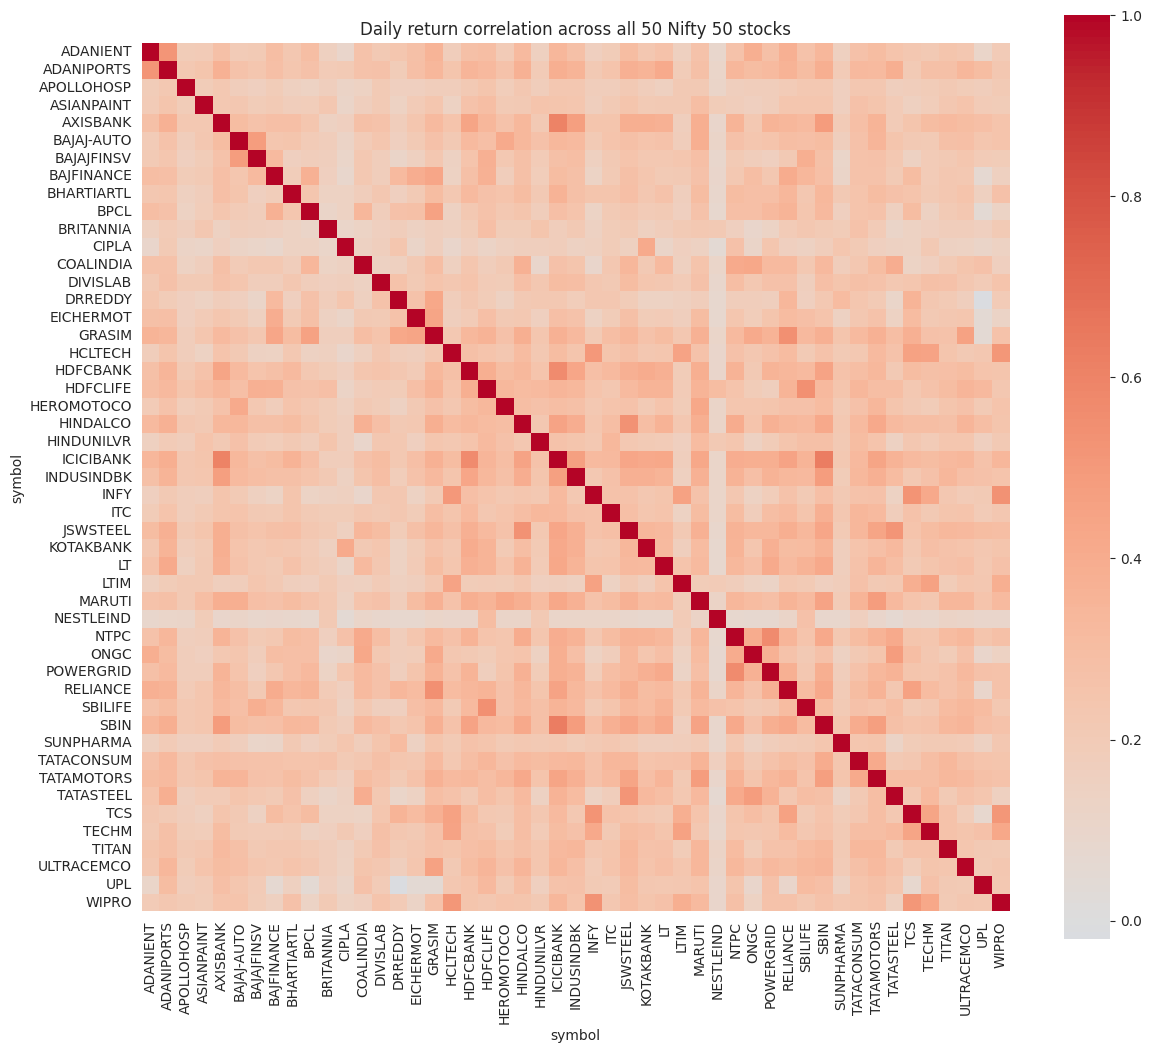

In [92]:
pivot_returns = df_clean.pivot(index='Date', columns='symbol', values='daily_return')
corr = pivot_returns.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True)
plt.title('Daily return correlation across all 50 Nifty 50 stocks')
plt.show()

In [93]:
corr_pairs = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

corr_pairs = corr_pairs.unstack().dropna()

corr_pairs.sort_values(
    ascending=False
).head(10)

symbol      symbol   
SBIN        ICICIBANK    0.626756
ICICIBANK   AXISBANK     0.601765
            HDFCBANK     0.566886
POWERGRID   NTPC         0.565256
RELIANCE    GRASIM       0.539207
SBILIFE     HDFCLIFE     0.538003
WIPRO       INFY         0.536042
JSWSTEEL    HINDALCO     0.535427
TCS         INFY         0.528744
ADANIPORTS  ADANIENT     0.520886
dtype: float64

In [82]:
df_clean['daily_return'].describe()

,daily_return
count,290597.000000
mean,0.000958
std,0.025911
min,-0.926483
25%,-0.010199
50%,0.000000
75%,0.011364
max,1.000000


In [94]:
df_clean['daily_return'].dtype

dtype('float64')

In [95]:
df_clean[['daily_return']].sample(10)

,daily_return
204664,0.004053
158800,-0.007154
21143,-0.011070
92755,0.000135
86517,-0.011398
218820,-0.010954
246522,0.113550
45951,0.030967
263938,-0.020579
255759,-0.009905


In [96]:
df_clean['daily_return'].describe()

,daily_return
count,290596.000000
mean,0.000955
std,0.025844
min,-0.926483
25%,-0.010199
50%,0.000000
75%,0.011364
max,0.950958


In [98]:
summary[summary['annualized_volatility'] > 0.6]
summary[summary['annualized_return'] < 0]
summary[summary['annualized_return'] > 0.45]

,symbol,avg_daily_return,daily_volatility,n_days,annualized_return,annualized_volatility,return_per_unit_risk
0,ADANIENT,0.001992,0.034932,5597,0.501961,0.554534,0.905194


In [99]:
SAMPLE_STOCK = 'DIVISLAB'
stock_df = df[df['symbol'] == SAMPLE_STOCK]

fig = go.Figure(data=[go.Candlestick(
    x=stock_df['Date'],
    open=stock_df['Open'], high=stock_df['High'],
    low=stock_df['Low'], close=stock_df['Close']
)])
fig.update_layout(title=f'{SAMPLE_STOCK} price history', xaxis_title='Date', yaxis_title='Price')
fig.show()

In [100]:
df_clean.to_csv('nifty50_cleaned.csv', index=False)
summary.to_csv('nifty50_risk_return_summary.csv', index=False)
drawdowns.to_csv('nifty50_drawdowns.csv', index=False)
print("Saved: nifty50_cleaned.csv, nifty50_risk_return_summary.csv, nifty50_drawdowns.csv")

Saved: nifty50_cleaned.csv, nifty50_risk_return_summary.csv, nifty50_drawdowns.csv
